Topic 5: NumPy


In [2]:
import numpy as np
import time

np.random.seed(42)

# ── 1. Array creation patterns ───────────────────────────────
print("=== ARRAY CREATION ===")
print(f"zeros:   {np.zeros((2,3))}")
print(f"eye:\n{np.eye(3)}")
print(f"linspace: {np.linspace(0, 1, 5)}")
print(f"randn shape: {np.random.randn(3, 4).shape}")

# ── 2. Indexing & Slicing ─────────────────────────────────────
print("\n=== INDEXING ===")
X = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90],
    [11, 22, 33],
])

print(f"First row:       {X[0]}")
print(f"Last row:        {X[-1]}")
print(f"Column 1:        {X[:, 1]}")
print(f"Rows 1-2:      \n{X[1:3]}")
print(f"Values > 50:     {X[X > 50]}")

# Fancy indexing — select specific rows by index
rows = np.array([0, 2, 3])
print(f"Rows 0,2,3:\n{X[rows]}")

# ── 3. Broadcasting ───────────────────────────────────────────
print("\n=== BROADCASTING ===")
scores = np.array([
    [85, 90, 78],
    [70, 88, 95],
    [60, 72, 80],
    [95, 85, 88],
], dtype=float)

# Subtract column mean (normalize each feature)
col_means = scores.mean(axis=0)   # shape (3,)
print(f"Column means: {col_means}")

normalized = scores - col_means   # (4,3) - (3,) → broadcasts!
print(f"Normalized:\n{np.round(normalized, 2)}")
print(f"New column means: {np.round(normalized.mean(axis=0), 6)}")

# ── 4. Axis operations ────────────────────────────────────────
print("\n=== AXIS OPERATIONS ===")
print(f"scores.sum(axis=0): {scores.sum(axis=0)}")  # per feature total
print(f"scores.sum(axis=1): {scores.sum(axis=1)}")  # per student total
print(f"scores.mean(axis=0): {scores.mean(axis=0)}")
print(f"scores.max(axis=1):  {scores.max(axis=1)}")  # each student's best

# ── 5. Vectorization speed comparison ────────────────────────
print("\n=== VECTORIZATION SPEED ===")
data = np.random.randn(1_000_000)

# Python loop
start = time.time()
result_loop = [x**2 for x in data]
loop_time = time.time() - start

# NumPy vectorized
start = time.time()
result_np = data ** 2
np_time = time.time() - start

print(f"Python loop: {loop_time:.4f}s")
print(f"NumPy:       {np_time:.4f}s")
print(f"Speedup:     {loop_time/np_time:.1f}x faster")

# ── 6. Practical ML operations ───────────────────────────────
print("\n=== ML OPERATIONS ===")

# Softmax (converts raw scores to probabilities)
def softmax(x):
    e_x = np.exp(x - x.max())   # subtract max for numerical stability
    return e_x / e_x.sum()

logits = np.array([2.0, 1.0, 0.5])
probs = softmax(logits)
print(f"Logits: {logits}")
print(f"Softmax: {np.round(probs, 4)}  (sums to {probs.sum():.1f})")

# ReLU activation
def relu(x):
    return np.maximum(0, x)

activations = np.array([-2, -1, 0, 1, 3])
print(f"\nReLU({activations}) = {relu(activations)}")

# Z-score normalization (StandardScaler)
def standardize(X):
    return (X - X.mean(axis=0)) / X.std(axis=0)

X_std = standardize(scores)
print(f"\nStandardized scores mean: {np.round(X_std.mean(axis=0), 6)}")
print(f"Standardized scores std:  {np.round(X_std.std(axis=0), 4)}")

=== ARRAY CREATION ===
zeros:   [[0. 0. 0.]
 [0. 0. 0.]]
eye:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
linspace: [0.   0.25 0.5  0.75 1.  ]
randn shape: (3, 4)

=== INDEXING ===
First row:       [10 20 30]
Last row:        [11 22 33]
Column 1:        [20 50 80 22]
Rows 1-2:      
[[40 50 60]
 [70 80 90]]
Values > 50:     [60 70 80 90]
Rows 0,2,3:
[[10 20 30]
 [70 80 90]
 [11 22 33]]

=== BROADCASTING ===
Column means: [77.5  83.75 85.25]
Normalized:
[[  7.5    6.25  -7.25]
 [ -7.5    4.25   9.75]
 [-17.5  -11.75  -5.25]
 [ 17.5    1.25   2.75]]
New column means: [0. 0. 0.]

=== AXIS OPERATIONS ===
scores.sum(axis=0): [310. 335. 341.]
scores.sum(axis=1): [253. 253. 212. 268.]
scores.mean(axis=0): [77.5  83.75 85.25]
scores.max(axis=1):  [90. 95. 80. 95.]

=== VECTORIZATION SPEED ===
Python loop: 0.0751s
NumPy:       0.0015s
Speedup:     50.9x faster

=== ML OPERATIONS ===
Logits: [2.  1.  0.5]
Softmax: [0.6285 0.2312 0.1402]  (sums to 1.0)

ReLU([-2 -1  0  1  3]) = [0 0 0 1 3]

Standardized

In [3]:
import numpy as np
np.random.seed(42)

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

X = np.random.randn(32, 8)

W1 = np.random.randn(8, 16) * 0.01
W2 = np.random.randn(16, 8) * 0.01
W3 = np.random.randn(8, 3) * 0.01

b1 = np.zeros(16)
b2 = np.zeros(8)
b3 = np.zeros(3)

Z1 = X @ W1 + b1
A1 = relu(Z1)
print(f"A1 : {A1.shape}")
Z2 = A1 @ W2 + b2
A2 = relu(Z2)
print(f"A2 : {A2.shape}")
Z3 = A2 @ W3 + b3
output = softmax(Z3)

print(f"output : {output.shape}")

print(f"rows sum should be 1(sample 5) : {output[:5].sum(axis = 1)}")

def predict(x):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    probs = softmax(Z3)

    return np.argmax(probs, axis= 1)

print(f"predicted : {predict(X)}")



A1 : (32, 16)
A2 : (32, 8)
output : (32, 3)
rows sum should be 1(sample 5) : [1. 1. 1. 1. 1.]
predicted : [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 2 1 0 0 0 1]


Topic 6: Pandas


In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

# ── 1. Create a realistic ML dataset ─────────────────────────
print("=== CREATING DATASET ===")

n = 100
df = pd.DataFrame({
    'age':        np.random.randint(22, 60, n),
    'salary':     np.random.randint(30000, 120000, n),
    'experience': np.random.randint(0, 20, n),
    'department': np.random.choice(['Engineering','Sales','HR','Marketing'], n),
    'promoted':   np.random.choice([0, 1], n, p=[0.7, 0.3]),
})

# Inject realistic mess
df.loc[5:10, 'salary'] = np.nan          # missing values
df.loc[15:17, 'age'] = np.nan
df = pd.concat([df, df.iloc[:5]])        # duplicate rows
df.loc[20, 'age'] = 200                  # outlier

print(f"Shape: {df.shape}")
print(df.head())

# ── 2. First-look diagnostics ─────────────────────────────────
print("\n=== DIAGNOSTICS ===")
print(df.info())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic stats:\n{df.describe().round(2)}")

# ── 3. Cleaning pipeline ──────────────────────────────────────
print("\n=== CLEANING ===")

# Fill missing salary with median (robust to outliers)
df['salary'] = df['salary'].fillna(df['salary'].median())

# Fill missing age with median
df['age'] = df['age'].fillna(df['age'].median())

# Cap age outlier
df['age'] = df['age'].clip(18, 80)

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)

print(f"After cleaning — shape: {df.shape}")
print(f"Nulls remaining: {df.isnull().sum().sum()}")
print(f"Age max after clip: {df['age'].max()}")

# ── 4. Selecting & filtering ──────────────────────────────────
print("\n=== FILTERING ===")

# Senior engineers earning above average
avg_sal = df['salary'].mean()
senior_eng = df[
    (df['department'] == 'Engineering') &
    (df['salary'] > avg_sal)
]
print(f"Senior engineers above avg salary: {len(senior_eng)}")

# Top 5 earners
top5 = df.nlargest(5, 'salary')[['age', 'salary', 'department']]
print(f"\nTop 5 earners:\n{top5}")

# ── 5. GroupBy analysis ───────────────────────────────────────
print("\n=== GROUPBY ===")

dept_stats = df.groupby('department').agg(
    avg_salary    = ('salary', 'mean'),
    avg_age       = ('age', 'mean'),
    promotion_rate= ('promoted', 'mean'),
    headcount     = ('promoted', 'count')
).round(2)

print(dept_stats)

# ── 6. Feature Engineering with Pandas ───────────────────────
print("\n=== FEATURE ENGINEERING ===")

# New features from existing columns
df['salary_per_year_exp'] = (df['salary'] / (df['experience'] + 1)).round(2)
df['age_group'] = pd.cut(df['age'], bins=[18,30,45,80],
                          labels=['junior','mid','senior'])
df['high_earner'] = (df['salary'] > df['salary'].quantile(0.75)).astype(int)

print(df[['age', 'experience', 'salary',
          'salary_per_year_exp', 'age_group', 'high_earner']].head(8))

# ── 7. Merging ────────────────────────────────────────────────
print("\n=== MERGING ===")

# Simulate a second table: department budgets
dept_budgets = pd.DataFrame({
    'department': ['Engineering', 'Sales', 'HR', 'Marketing'],
    'budget_usd':  [500000, 300000, 150000, 200000]
})

df_merged = pd.merge(df, dept_budgets, on='department', how='left')
print(f"Merged shape: {df_merged.shape}")
print(df_merged[['department', 'salary', 'budget_usd']].head(4))

=== CREATING DATASET ===
Shape: (105, 5)
    age    salary  experience   department  promoted
0  50.0  100592.0           3    Marketing         0
1  36.0   38110.0          18           HR         1
2  29.0  109309.0           2    Marketing         1
3  42.0   57266.0          18        Sales         0
4  40.0   82992.0          19  Engineering         0

=== DIAGNOSTICS ===
<class 'pandas.DataFrame'>
Index: 105 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         102 non-null    float64
 1   salary      99 non-null     float64
 2   experience  105 non-null    int32  
 3   department  105 non-null    str    
 4   promoted    105 non-null    int64  
dtypes: float64(2), int32(1), int64(1), str(1)
memory usage: 8.6 KB
None

Missing values:
age           3
salary        6
experience    0
department    0
promoted      0
dtype: int64

Basic stats:
          age     salary  experience  promoted
cou

In [5]:
import pandas as pd
import numpy as np

np.random.seed(0)

# Dataset: student exam results across 3 subjects
df = pd.DataFrame({
    'student_id': range(1, 51),
    'name':       [f'Student_{i}' for i in range(1, 51)],
    'math':       np.random.randint(40, 100, 50),
    'physics':    np.random.randint(30, 100, 50),
    'chemistry':  np.random.randint(35, 100, 50),
    'school':     np.random.choice(['School_A','School_B','School_C'], 50),
    'study_hours':np.random.randint(1, 10, 50),
})

# Inject mess
df.loc[[3, 7, 15, 23], 'math'] = np.nan
df.loc[[10, 20], 'physics'] = np.nan
df = pd.concat([df, df.iloc[:3]]).reset_index(drop=True)
df.loc[0, 'math'] = 200   # outlier

print(f"Shape : {df.shape}")
print("\nHead :")
print(df.head())
print("\nInfo :")
print(df.info())
print("\nDescription :")
print(df.describe())
print("\nMissing values :")
print(df.isnull().sum())

#Cleaning
df["math"] = df["math"].fillna(df['math'].median())
df["physics"] = df["physics"].fillna(df["physics"].mean())
df['math'] = df['math'].clip(0, 100)
df = df.drop_duplicates()[:50]

#adding 3 new columns
df["total"] = df["math"] + df["physics"] +df["chemistry"]
df["average"] = df["total"]/3
df["grade"] = pd.cut(df["average"], bins = [0, 60, 75, 100], labels = ["C", "B", "A"])

#GroupBy school
school_stats = df.groupby("school").agg(
    avg_total = ("total", "mean"),
    avg_study_hours = ("study_hours", "mean")
)

best_school = school_stats["avg_total"].idxmax()
print(f"{best_school} has the best performance")

#top 5 students
top5 = df.nlargest(5, "average")[["name", "school", "average", "grade"]]
print(top5)

school_locations = pd.DataFrame({
    "school" : ["School_A", "School_B", "School_C"],
    "locations" : ["Hyderabad", "Mumbai", "Banglore"]
})

df_merged = pd.merge(df, school_locations, on="school", how="left")
print(df_merged.head())

Shape : (53, 7)

Head :
   student_id       name   math  physics  chemistry    school  study_hours
0           1  Student_1  200.0     95.0         35  School_A            6
1           2  Student_2   87.0     39.0         85  School_A            8
2           3  Student_3   93.0     87.0         71  School_B            1
3           4  Student_4    NaN     62.0         69  School_A            9
4           5  Student_5   43.0     61.0         83  School_C            5

Info :
<class 'pandas.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   53 non-null     int64  
 1   name         53 non-null     str    
 2   math         49 non-null     float64
 3   physics      51 non-null     float64
 4   chemistry    53 non-null     int32  
 5   school       53 non-null     str    
 6   study_hours  53 non-null     int32  
dtypes: float64(2), int32(2), int64(1), str(2)
me

Topic 7: Data Visualization

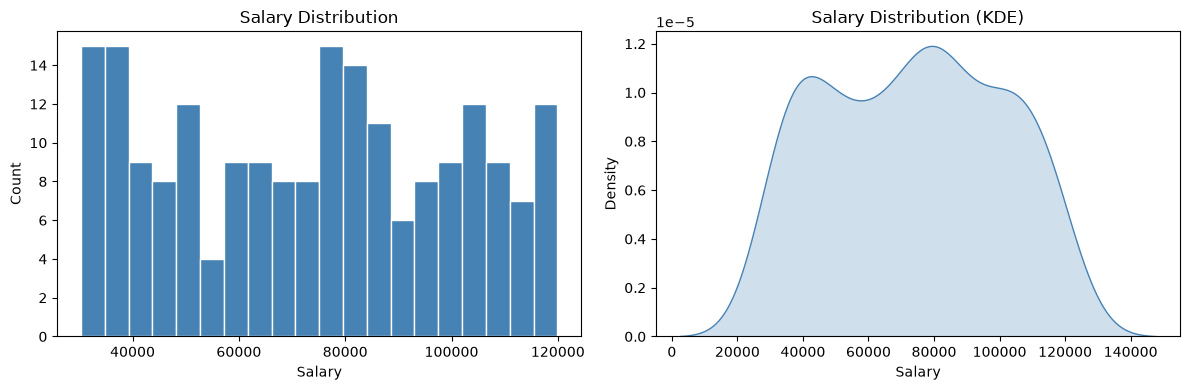

Saved: 01_histogram.png


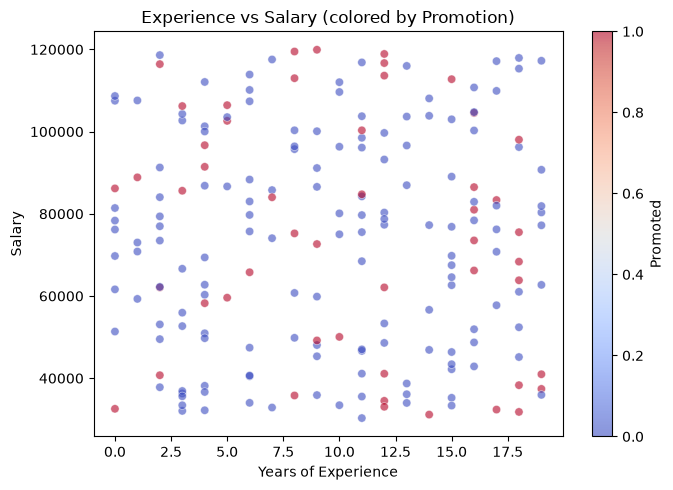

C:\Users\B Sushant Kumar\AppData\Local\Temp\ipykernel_19968\1280234720.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='department', y='salary',


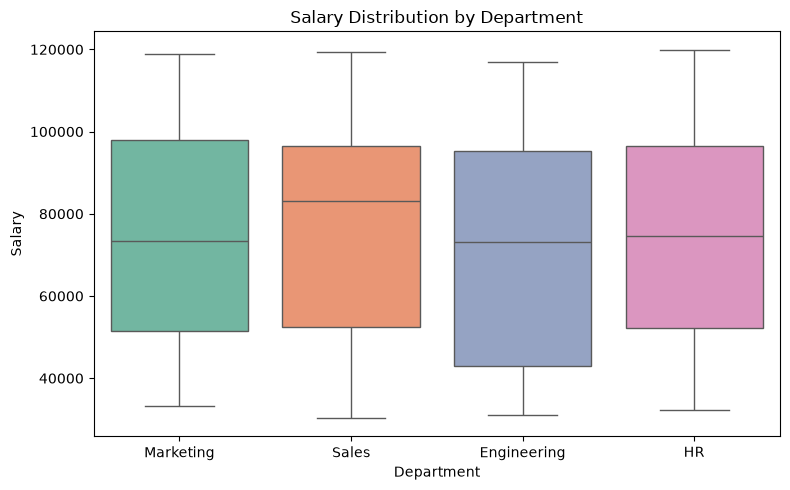

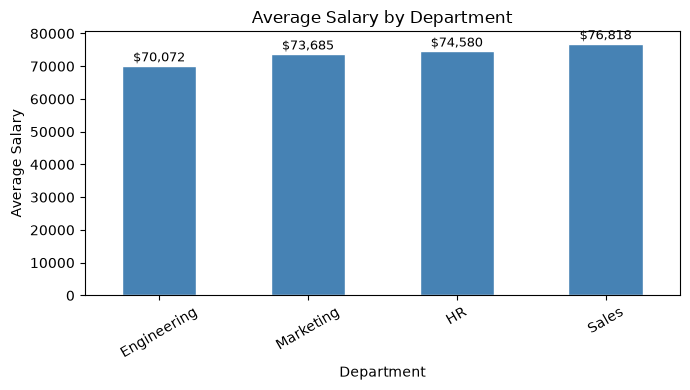

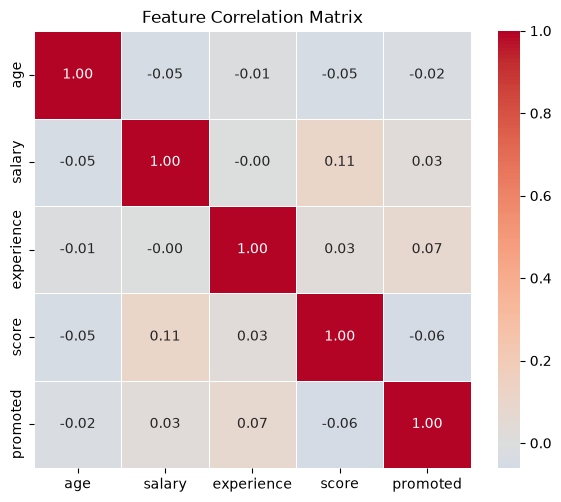

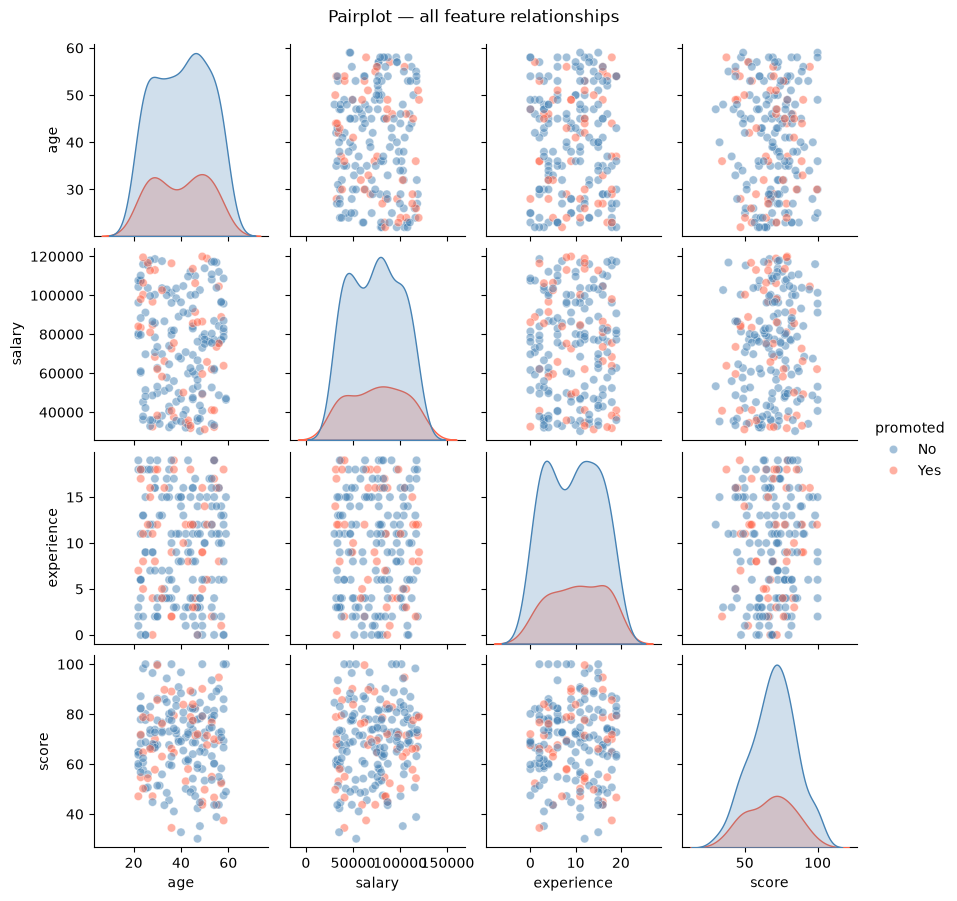

All plots saved.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# ── Dataset ──────────────────────────────────────────────────
n = 200
df = pd.DataFrame({
    'age':        np.random.randint(22, 60, n),
    'salary':     np.random.randint(30000, 120000, n),
    'experience': np.random.randint(0, 20, n),
    'department': np.random.choice(['Engineering','Sales','HR','Marketing'], n),
    'promoted':   np.random.choice([0, 1], n, p=[0.7, 0.3]),
    'score':      np.random.normal(70, 15, n).clip(0, 100),
})

# ── 1. Histogram — distribution of one variable ───────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['salary'], bins=20, color='steelblue',
             edgecolor='white')
axes[0].set_title('Salary Distribution')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Count')

# KDE (smooth version of histogram) — via Seaborn
sns.kdeplot(df['salary'], ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('Salary Distribution (KDE)')
axes[1].set_xlabel('Salary')

plt.tight_layout()
plt.savefig('01_histogram.png', dpi=100)
plt.show()
print("Saved: 01_histogram.png")

# ── 2. Scatter — relationship between two variables ───────────
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(
    df['experience'], df['salary'],
    c=df['promoted'],           # color by promotion status
    cmap='coolwarm',
    alpha=0.6, edgecolors='white', linewidth=0.5
)
plt.colorbar(scatter, ax=ax, label='Promoted')
ax.set_title('Experience vs Salary (colored by Promotion)')
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Salary')
plt.tight_layout()
plt.savefig('02_scatter.png', dpi=100)
plt.show()

# ── 3. Box plot — distributions across categories ────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='department', y='salary',
            palette='Set2', ax=ax)
ax.set_title('Salary Distribution by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Salary')
plt.tight_layout()
plt.savefig('03_boxplot.png', dpi=100)
plt.show()

# ── 4. Bar plot — comparing category means ───────────────────
dept_avg = df.groupby('department')['salary'].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
dept_avg.plot(kind='bar', ax=ax, color='steelblue',
              edgecolor='white')
ax.set_title('Average Salary by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Average Salary')
ax.tick_params(axis='x', rotation=30)

# Add value labels on bars
for i, val in enumerate(dept_avg):
    ax.text(i, val + 500, f'${val:,.0f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('04_barplot.png', dpi=100)
plt.show()

# ── 5. Correlation Heatmap — the ML staple ───────────────────
fig, ax = plt.subplots(figsize=(6, 5))

corr = df[['age','salary','experience','score','promoted']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True,
            linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('05_heatmap.png', dpi=100)
plt.show()

# ── 6. Pair plot — full feature relationships at once ─────────
pair_df = df[['age','salary','experience','score']].copy()
pair_df['promoted'] = df['promoted'].map({0:'No', 1:'Yes'})

g = sns.pairplot(pair_df, hue='promoted',
                 palette={'No':'steelblue','Yes':'tomato'},
                 plot_kws={'alpha':0.5}, height=2.2)
g.figure.suptitle('Pairplot — all feature relationships', y=1.02)
plt.savefig('06_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()
print("All plots saved.")

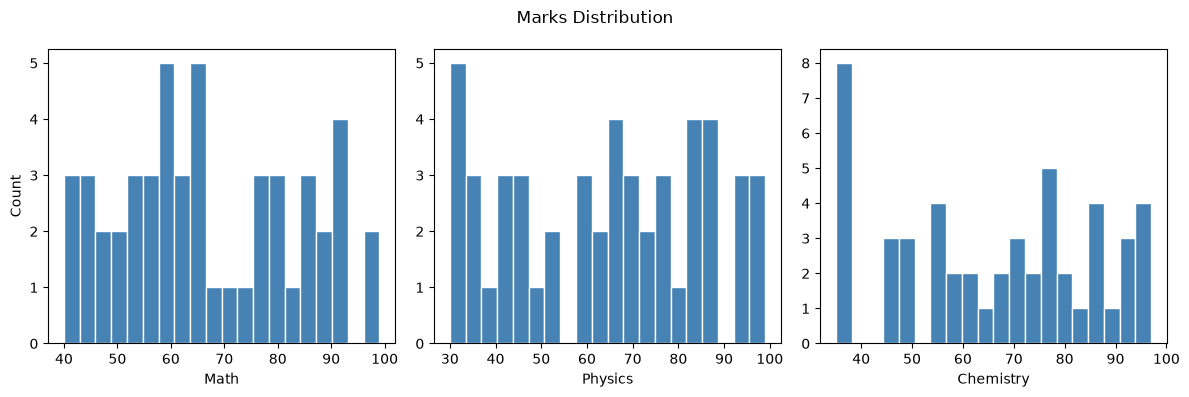

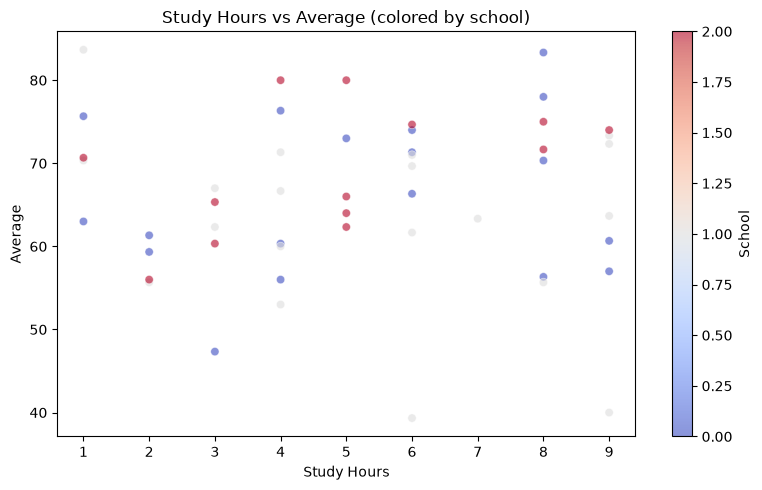

C:\Users\B Sushant Kumar\AppData\Local\Temp\ipykernel_19968\2185459878.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="school", y="average",


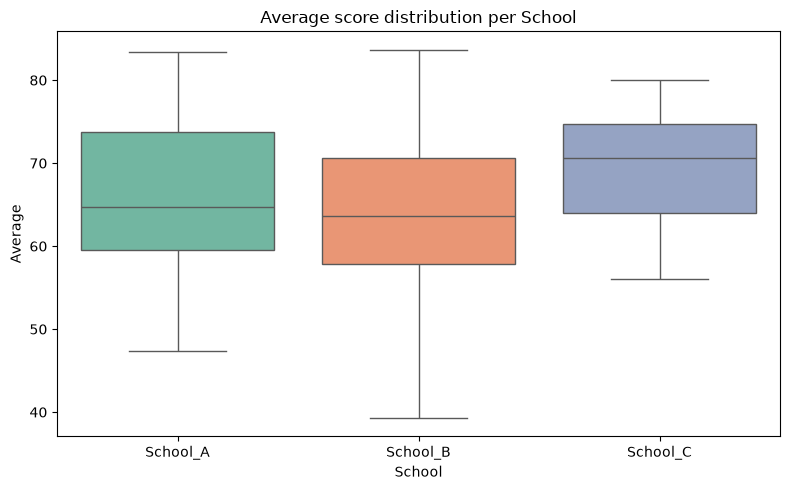

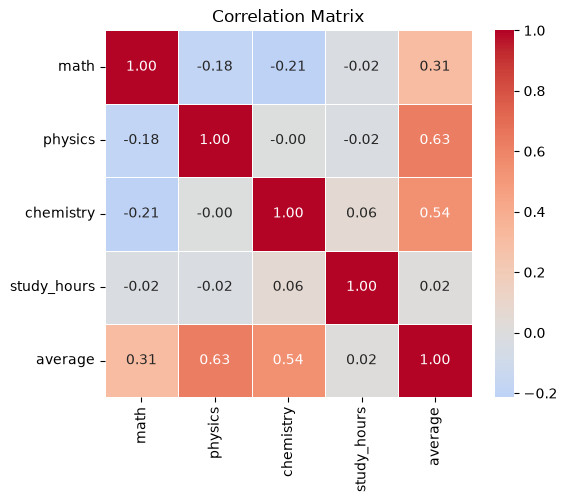

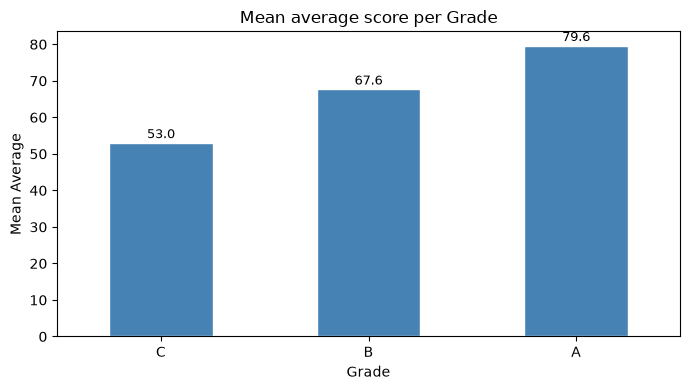

C:\Users\B Sushant Kumar\AppData\Local\Temp\ipykernel_19968\2185459878.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


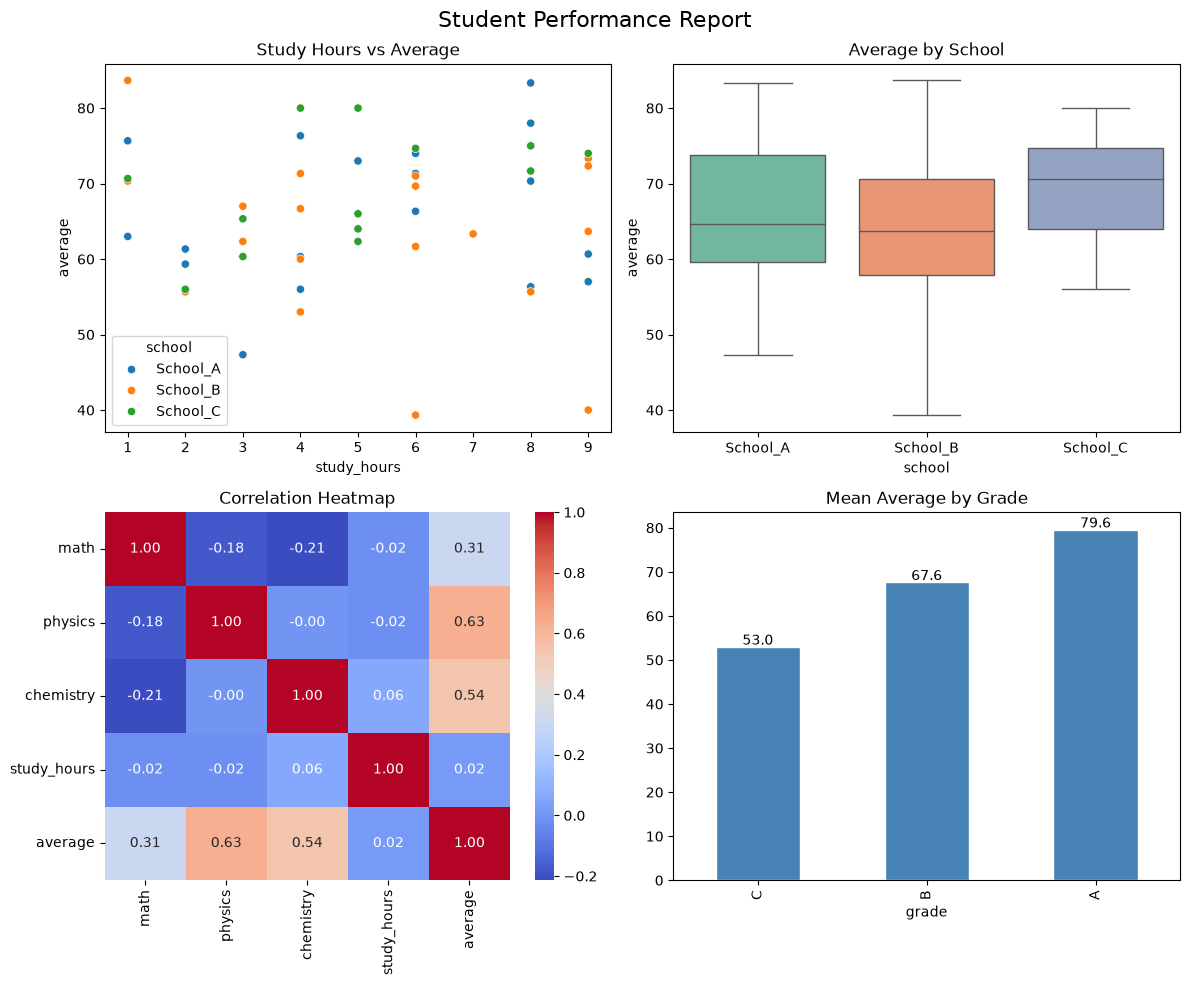

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)

# Reuse the student dataset from Topic 6
df = pd.DataFrame({
    'student_id':  range(1, 51),
    'math':        np.random.randint(40, 100, 50),
    'physics':     np.random.randint(30, 100, 50),
    'chemistry':   np.random.randint(35, 100, 50),
    'school':      np.random.choice(['School_A','School_B','School_C'], 50),
    'study_hours': np.random.randint(1, 10, 50),
})

df['total'] = df['math'] + df['physics'] + df['chemistry']
df['average'] = df['total']/3
df['grade'] = pd.cut(df['average'],
                     bins=[0, 60, 75, 100],
                     labels=['C', 'B', 'A'])

# TODO 1: Plot histograms of math, physics, chemistry
#         on the same figure (1 row, 3 columns)
#         Add a title to the overall figure
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].hist(df['math'], bins=20, color='steelblue', edgecolor='white')
ax[0].set_xlabel("Math")
ax[0].set_ylabel("Count")

ax[1].hist(df['physics'], bins=20, color='steelblue', edgecolor='white')
ax[1].set_xlabel("Physics")

ax[2].hist(df['chemistry'], bins=20, color='steelblue', edgecolor='white')
ax[2].set_xlabel("Chemistry")

fig.suptitle("Marks Distribution")

plt.tight_layout()
plt.show()


# TODO 2: Scatter plot — study_hours vs average score
#         Color the dots by school
#         Add axis labels and title
fig, ax = plt.subplots(figsize=(8, 5))

school_codes = df["school"].astype("category").cat.codes

scatter = ax.scatter(df["study_hours"], df['average'],
                     c=school_codes, cmap="coolwarm",
                     alpha=0.6, edgecolors="white", linewidths=0.5)

plt.colorbar(scatter, ax=ax, label="School")
ax.set_title("Study Hours vs Average (colored by school)")
ax.set_xlabel("Study Hours")
ax.set_ylabel("Average")
plt.tight_layout()
plt.show()


# TODO 3: Box plot — average score distribution per school
#         Which school has the most consistent scores?
#         (Hint: smallest box = least variance)
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x="school", y="average",
            palette="Set2", ax=ax)
ax.set_title("Average score distribution per School")
ax.set_xlabel("School")
ax.set_ylabel("Average")
plt.tight_layout()
plt.show()


# TODO 4: Correlation heatmap of
#         [math, physics, chemistry, study_hours, average]
#         Which two subjects are most correlated?
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[["math", "physics", "chemistry", "study_hours", "average"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax, square=True, linewidths=0.5)

ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


# TODO 5: Bar chart — mean average score per grade (A, B, C)
#         Sort bars from highest to lowest
#         Add value labels on top of each bar
grade_avg = df.groupby("grade", observed=True)["average"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
grade_avg.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")

ax.set_title("Mean average score per Grade")
ax.set_xlabel("Grade")
ax.set_ylabel("Mean Average")
ax.tick_params(axis='x', rotation=0)

for i, val in enumerate(grade_avg):
    ax.text(
        i, val + 0.5, f"{val:.1f}", ha="center", va="bottom", fontsize=9
    )
plt.tight_layout()
plt.show()

# STRETCH GOAL:
# Create a 2x2 figure grid containing
# your best 4 plots from above — all in one clean figure
# Add a main title with plt.suptitle()
# Save it as 'student_report.png'

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter
sns.scatterplot(
    data=df,
    x='study_hours',
    y='average',
    hue='school',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Study Hours vs Average')

# Boxplot
sns.boxplot(
    data=df,
    x='school',
    y='average',
    palette='Set2',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Average by School')

# Heatmap
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Correlation Heatmap')

# Bar chart
grade_avg.plot(
    kind='bar',
    ax=axes[1, 1],
    color='steelblue',
    edgecolor='white'
)
axes[1, 1].set_title('Mean Average by Grade')

for i, val in enumerate(grade_avg):
    axes[1, 1].text(
        i,
        val + 0.5,
        f'{val:.1f}',
        ha='center'
    )

plt.suptitle('Student Performance Report', fontsize=16)

plt.tight_layout()
plt.savefig('student_report.png', dpi=100)
plt.show()


